In [1]:
import pandas as pd
import random
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

import sys
from pathlib import Path
import os

from torch.utils.tensorboard import SummaryWriter
#from skimage.metrics import peak_signal_noise_ratio, structural_similarity

import albumentations as A
from albumentations.pytorch import ToTensorV2


/home/jorge/miniconda3/envs/image-recon-dl-env/lib/python3.10/site-packages/albumentations/__init__.py:24: UserWarning: A new version of Albumentations is available: 1.4.24 (you have 1.4.21). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()


In [2]:
# Semilla para reproducibilidad de los experimentos
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

In [3]:
# Me aseguro de que el directorio raíz del proyecto esté en el sys.path
project_root = Path(os.path.abspath("")).parent

# Añado el directorio raíz al sys.path si no está ya presente
if project_root not in sys.path:
    sys.path.append(str(project_root))

In [4]:
# Importo las funciones de configuración
from src.config import processed_data_dir, models_dir, reports_dir, load_config

from src.utils.datasets import CustomDataset_2_2

from src.models.convolutional_autoencoder_model.model import ConvolutionalAutoencoder
from src.models.convolutional_autoencoder_model.train_model import train_model


Current working directory: /home/jorge/development/WasteImageReconstructionDL/notebooks
Loading configuration from /home/jorge/development/WasteImageReconstructionDL/src/config.yaml


In [5]:
# Cargo la configuración 
config = load_config()

Loading configuration from /home/jorge/development/WasteImageReconstructionDL/src/config.yaml


In [6]:
# Transformación de las imágenes
transform = transforms.Compose([
    transforms.Resize((256, 256)),  # Asegurar que las imágenes tengan el mismo tamaño
    transforms.ToTensor(),
])

In [7]:
# Definir el pipeline de augmentación
augmentation_pipeline = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.OneOf([
        A.Rotate(limit=(0, 0), p=0.33),
        A.Rotate(limit=(180, 180), p=0.33),
        A.Compose([A.Rotate(limit=(180, 180), p=1.0), A.HorizontalFlip(p=1.0)], p=0.34)
    ], p=1.0)
])

In [8]:
# Ruta de los datos
final_data_dir = processed_data_dir() 

In [9]:
# Definir la ruta de los archivos CSV
train_csv = os.path.join(final_data_dir, 'train.csv')
val_csv = os.path.join(final_data_dir, 'val.csv')

In [10]:
# Crear el dataset
train_dataset = CustomDataset_2_2(
    csv_file=os.path.join(final_data_dir, 'train.csv'),
    transform=transform,
    augmentation_pipeline=augmentation_pipeline,
    use_augmentation=True  # Activar Data Augmentation para el entrenamiento y probar con imágenes aumentadas
)

val_dataset = CustomDataset_2_2(
    csv_file=os.path.join(final_data_dir, 'val.csv'),
    transform=transform,
    use_augmentation=False  # No activar Data Augmentation para el conjunto de validación
)

In [11]:
# Si tenemos disponible GPU, lo usamos
# Chequeamos si tenemos disponible GPU (CUDA)
if torch.cuda.is_available():
    device = "cuda"
# Chequeamos si tenemos disponible aceleración por hardware en un chip de Apple (MPS)
elif torch.backends.mps.is_available():
    device = "mps"
# Por defecto usamos CPU
else:
    device = "cpu"

In [12]:
# Crear los dataloaders
batch_size = 8
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=4)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=4)

In [13]:
# Definir el modelo con diferentes números de filtros
encoder_filters = [64, 128, 256, 512, 1024, 2048]
decoder_filters = [2048, 1024, 512, 256, 128, 64]
model = ConvolutionalAutoencoder(encoder_filters, decoder_filters).to(device)


In [14]:
# Definir el criterio y el optimizador
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=3, factor=0.5)

In [15]:
nombre_modelo = 'cae_model'
output_model_path = models_dir() / "trained"
os.makedirs(output_model_path, exist_ok=True)

In [16]:
# Defino directorio base de logs para tensorboard
log_base_dir = reports_dir()/'logs'
os.makedirs(log_base_dir, exist_ok=True)

In [17]:
# Defino subdirectorio de logs para este modelo
log_dir = log_base_dir / nombre_modelo
os.makedirs(log_dir, exist_ok=True)

In [18]:
# Definir el número de épocas y la mejor pérdida de validación
num_epochs = 100
early_stop_patience = 5


In [19]:
print(log_dir)

/home/jorge/development/WasteImageReconstructionDL/reports/logs/cae_model


In [20]:
# Inicializar tensorboard
writer = SummaryWriter(log_dir=str(log_dir), comment="Run_cae_model")

In [21]:
%load_ext tensorboard

%tensorboard --logdir=../reports/logs --host 0.0.0.0 --port 6006


In [22]:
# Entrenamiento del modelo
train_losses, val_losses, val_psnr_values, val_ssim_values, compression_ratios = (
    train_model(
        model,
        train_loader,
        val_loader,
        criterion,
        optimizer,
        scheduler,
        num_epochs,
        device,
        writer,
        output_model_path,
        nombre_modelo,
        early_stop_patience,
    )
)

Epoch [1/100], Train Loss: 0.0441, Val Loss: 0.0330, Val PSNR: 12.5108, Val SSIM: 0.2092, Compression Ratio: 6.00
Epoch [2/100], Train Loss: 0.0203, Val Loss: 0.0170, Val PSNR: 15.4678, Val SSIM: 0.2341, Compression Ratio: 6.00
Epoch [3/100], Train Loss: 0.0156, Val Loss: 0.0168, Val PSNR: 16.5567, Val SSIM: 0.2438, Compression Ratio: 6.00
Epoch [4/100], Train Loss: 0.0140, Val Loss: 0.0133, Val PSNR: 17.5231, Val SSIM: 0.2490, Compression Ratio: 6.00
Epoch [5/100], Train Loss: 0.0131, Val Loss: 0.0127, Val PSNR: 17.6975, Val SSIM: 0.2516, Compression Ratio: 6.00
Epoch [6/100], Train Loss: 0.0123, Val Loss: 0.0125, Val PSNR: 17.9157, Val SSIM: 0.2589, Compression Ratio: 6.00
Epoch [7/100], Train Loss: 0.0120, Val Loss: 0.0130, Val PSNR: 17.7069, Val SSIM: 0.2644, Compression Ratio: 6.00
Epoch [8/100], Train Loss: 0.0116, Val Loss: 0.0114, Val PSNR: 18.5519, Val SSIM: 0.2663, Compression Ratio: 6.00
Epoch [9/100], Train Loss: 0.0113, Val Loss: 0.0113, Val PSNR: 18.5434, Val SSIM: 0.2669

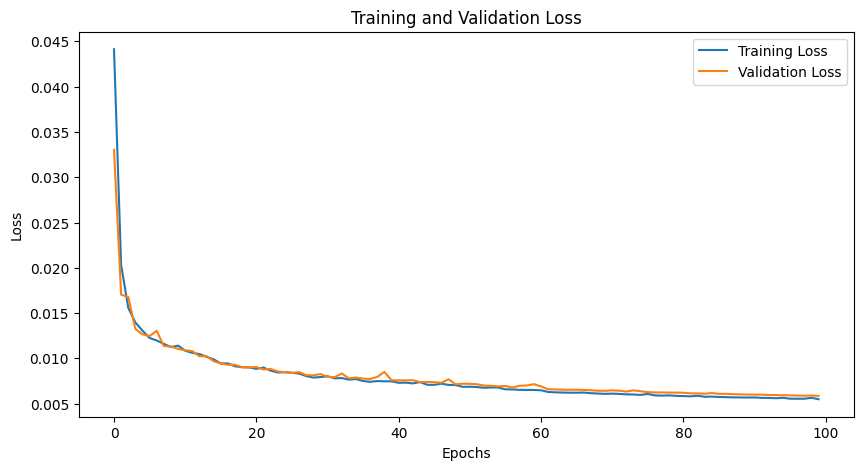

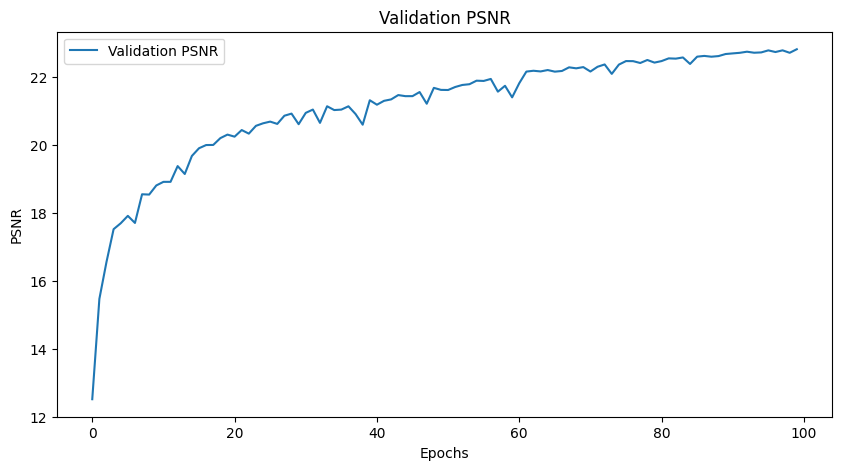

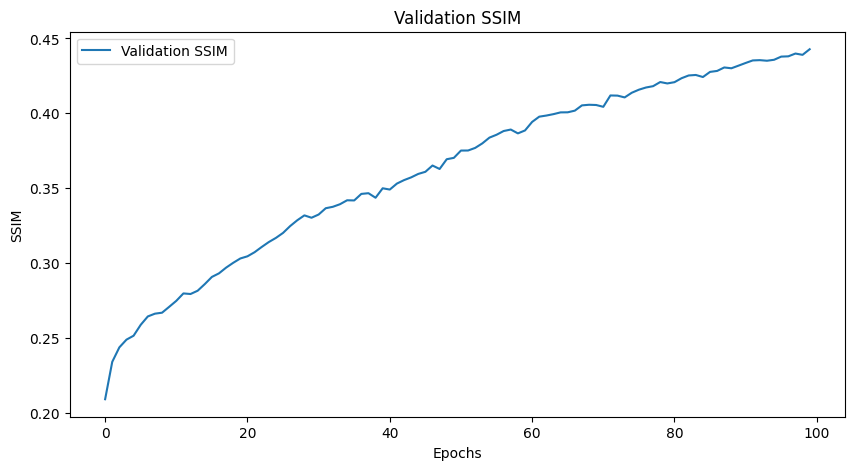

In [23]:
# Graficar las pérdidas de entrenamiento y validación
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Training and Validation Loss')
plt.show()

# Graficar PSNR y SSIM de validación
plt.figure(figsize=(10, 5))
plt.plot(val_psnr_values, label='Validation PSNR')
plt.xlabel('Epochs')
plt.ylabel('PSNR')
plt.legend()
plt.title('Validation PSNR')
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(val_ssim_values, label='Validation SSIM')
plt.xlabel('Epochs')
plt.ylabel('SSIM')
plt.legend()
plt.title('Validation SSIM')
plt.show()